In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform

# **Function 7** — ML Hyperparameter Tuning (6D)

Optimising six hyperparameters (e.g. learning rate, regularisation, hidden layers) to maximise model performance score.

- **Optimisation Goal:** Maximise
- **Input:** 6D
- **All-time best:** 1.717 at [0.075, 0.405, 0.383, 0.205, 0.437, 0.747] (Week 5)

Loading the cumulative dataset and appending the Week 7 result.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 7
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy')

# New data for Week 8 (Function 7)
X_w7_new_point = np.array([0.114899, 0.037728, 0.781258, 0.494700, 0.114078, 0.883059], dtype=np.float64)
Y_w7_new_point = np.array([0.7546575942392093], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w7_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w7_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 7: ", X_unique)
print("Updated Outputs (Y) - Function 7: ", Y_updated)

Updated Inputs (X) - Function 7:  [[0.001234   0.887611   0.445322   0.221098   0.990123   0.556712  ]
 [0.004352   0.329864   0.487139   0.079703   0.323502   0.982761  ]
 [0.010322   0.277175   0.892712   0.174897   0.395748   0.738827  ]
 [0.017847   0.815326   0.270978   0.212167   0.499065   0.497593  ]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.06661051 0.52804507 0.8160952  0.96101714 0.08650933 0.77778822]
 [0.075291   0.40479    0.382733   0.204853   0.437087   0.746748  ]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.114899   0.037728   0.781258   0.4947     0.114078   0.883059  ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.14864702 0.03394336 0.72880565 0.31606646 0.02176938 0.51691776]
 [0.17597754 0.6244165  0.29554198 0.46955276 0.09776977 0.72814108]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]


## Output Analysis

- Last week (w6) I got the result of 1.327, this week (w7) the output dropped to 0.755.
    - This is further away from the w5 all-time best of 1.717

- **Real-World Implication:** The w7 query produced the worst result since the early weeks. 
    - Comparing w7 [0.115, 0.038, 0.781, 0.495, 0.114, 0.883] to the w5 best [0.075, 0.405, 0.383, 0.205, 0.437, 0.747], the two largest deviations are x2 (0.038 vs 0.405, difference of -0.37) and x3 (0.781 vs 0.383, difference of +0.40).

    - These are almost perfectly opposite, suggesting the focused grid with std=0.05 from w7 was still too wide and the model sampled a point far from the peak.

- **Model Clues:** The w5 coordinates are the only configuration that has produced above 1.5.
    - x3≈0.383 and x2≈0.405 appear to be the most critical dimensions, both must be in the moderate range. 
    - High x3 (above 0.7) consistently produces poor results.

- **Key change for w8:** Tighten focused grid to std=0.02 (from 0.05 in w7). 
    - The w5 coordinates must be followed much more precisely.

## Bayesian Optimisation — Gaussian Process Regressor

- **Model:** ConstantKernel × Matern (nu=2.5, ARD 6D) + WhiteKernel with Yeo-Johnson output transformation.

- **Changes for W8:**
    - Kernel held constant — ARD has been learning the relative sensitivity of the six hyperparameters across 7 weeks and this should not be reset.
    
    - Yeo-Johnson transformation retained.

    - **Intended impact:** Use the w7 regression (particularly the extreme x3=0.781 result) as strong boundary evidence that steers the GP firmly away from high x3 values and back toward the W5 profile.

In [3]:
# Yeo-Johnson Output Transformation (HEBO)
Y_transformed = power_transform(
    Y_updated.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print('Original Y:   ', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = C(1.0) * Matern(length_scale=[0.1]*6, nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=False
)

model.fit(X_unique, Y_transformed)
print('\nFitted kernel:', model.kernel_)

Original Y:    [0.11990281 0.86440358 1.32634849 0.25791128 1.3649683  0.51645722
 1.71684115 0.00882563 0.00750324 0.75465759 0.0614243  0.61152553
 0.47539552 0.09264495 0.83359509 0.00701603 0.6044327  0.04211835
 0.27489251 0.09541116 0.0735163  0.01820907 0.56275307 0.2730468
 0.0178696  0.10050661 0.2063097  0.06676325 0.08374657 0.03356494
 0.02134252 0.01479818 0.00313433 0.00270147 0.67514163 0.00377748
 0.26840032]
Transformed Y: [-0.34263556  1.40020087  1.67155332  0.28007078  1.68608901  0.95540174
  1.78640193 -1.09118086 -1.10195575  1.29367268 -0.70116963  1.11234658
  0.87585555 -0.50107244  1.37262174 -1.10593853  1.10178962 -0.8360272
  0.34038322 -0.48433575 -0.62115183 -1.01618043  1.03617236  0.33396931
 -1.01885    -0.45390587  0.07730367 -0.66543224 -0.55597196 -0.89873586
 -0.99169176 -1.04315121 -1.13792233 -1.141517    1.19991398 -1.13259188
  0.31767172]

Fitted kernel: 0.97**2 * Matern(length_scale=[1.56, 0.47, 9.07e+03, 0.669, 0.412, 0.385], nu=2.5) + Whit

/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 4/Week Function Analysis/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## **Acquisition Function**: UCB (beta=2.0) with Tight Focused Grid (std=0.02)

- **Strategy:** UCB with beta=2.0 maintained as it provides a balanced exploration/exploitation for the 6D space.

- **Key change for W8:** Tighten focused grid to **std=0.02** (from 0.05 in w7). 
    - This is the critical fix — w7's std=0.05 allowed x3 to drift to 0.781, which was catastrophic. 
    - std=0.02 confines the search to a much smaller neighbourhood of the w5 peak. 
    - An 80/20 focused/uniform split.

- **Intended impact:** Recover to 1.717 or above by staying precisely within the confirmed high-performance region around the w5 coordinates.

In [4]:
def upper_confidence_bound(X, model, beta=2.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

# Tight focused grid centred on W5 all-time best
w5_best = np.array([0.075291, 0.404790, 0.382733, 0.204853, 0.437087, 0.746748])

x_focused = np.clip(
    np.random.normal(loc=w5_best, scale=0.02, size=(120000, 6)),
    0.000001, 0.999999
)
x_uniform = np.random.uniform(0.000001, 0.999999, (30000, 6))
x_grid = np.vstack([x_focused, x_uniform])

ucb_values = upper_confidence_bound(x_grid, model, beta=2.0)
next_query = x_grid[np.argmax(ucb_values)]

print(f'W5 best coordinates: {w5_best}')
print(f'Strategic Week 8 Query (Function 7): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}')

W5 best coordinates: [0.075291 0.40479  0.382733 0.204853 0.437087 0.746748]
Strategic Week 8 Query (Function 7): 0.022693-0.458610-0.588169-0.516538-0.194504-0.964834


## **Visualisation**: Optimisation Progress

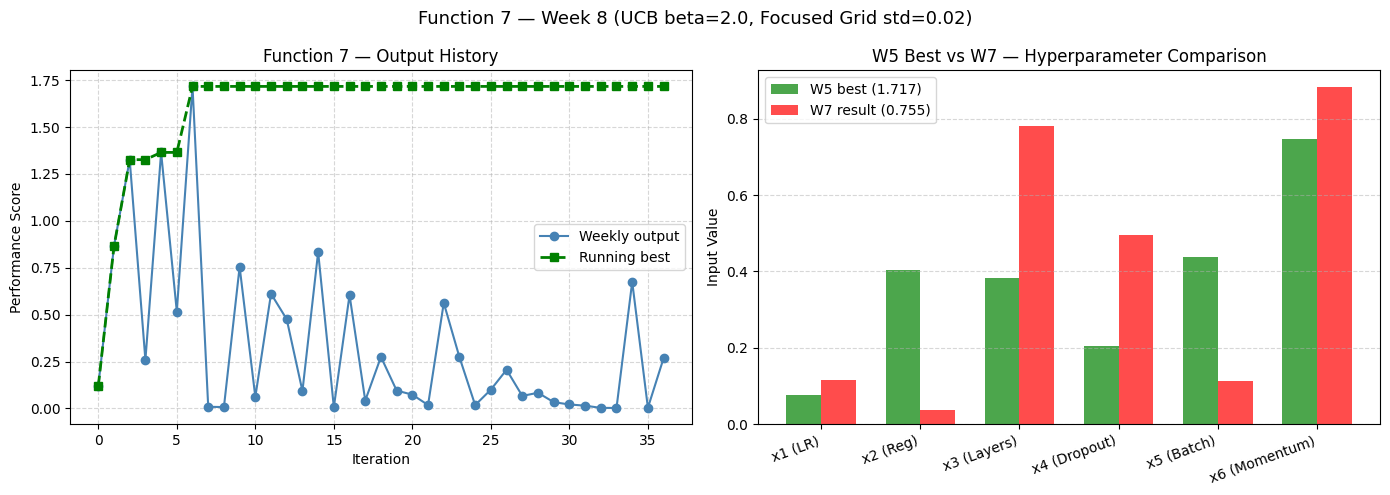

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 7 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Performance Score')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Compare W5 best vs W7 input profiles
hp_labels = ['x1 (LR)', 'x2 (Reg)', 'x3 (Layers)', 'x4 (Dropout)', 'x5 (Batch)', 'x6 (Momentum)']
x_pos = np.arange(len(hp_labels))
width = 0.35
axes[1].bar(x_pos - width/2, w5_best, width, label='W5 best (1.717)', color='green', alpha=0.7)
axes[1].bar(x_pos + width/2, X_w7_new_point, width, label='W7 result (0.755)', color='red', alpha=0.7)
axes[1].set_title('W5 Best vs W7 — Hyperparameter Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(hp_labels, rotation=20, ha='right')
axes[1].set_ylabel('Input Value')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 7 — Week 8 (UCB beta=2.0, Focused Grid std=0.02)', fontsize=13)
plt.tight_layout()
plt.show()